# Visualiser le risque de réadmission à 30 jours avec des graphiques d'effets basés sur le modèle


## Synthèse

Ce notebook ajuste une régression logistique de la réadmission hospitalière à 30 jours selon des caractéristiques de patient et de séjour, puis traduit les coefficients ajustés en graphiques d'effets basés sur le modèle à l'échelle de la probabilité prédite. Sur une cohorte synthétique de 100 sorties (55 réadmissions), PROC LOGISTIC retrouve des gradients significatifs pour la **durée de séjour** (OR 1,36 par jour, *p* = 0,040) et l'**âge** (OR 1,05 par an, *p* = 0,023), ainsi qu'un fort effet du payeur — les patients **Medicaid** portent environ six fois la cote de réadmission de Medicare (OR 6,02, IC à 95 % 1,46–24,8, *p* = 0,013). Le R-carré généralisé est de 0,246 et le test de Hosmer–Lemeshow ne montre aucun défaut d'ajustement (*p* = 0,73). Les affichages de courbe d'ajustement, d'ajustement en tranches et d'interaction montrent ensuite comment le risque de réadmission grimpe avec la durée de séjour, comment le gradient âge–risque se déplace selon le payeur, et comment l'écart entre payeurs persiste à travers les lignes de service de sortie — le type de vue de stratification du risque qu'une équipe de gestion des soins utilise pour cibler le suivi post-sortie.


## Sources de données

| Jeu de données | Lignes | Description |
|---------|------|-------------|
| `encounters` | 100 | Enregistrements synthétiques de sorties d'hospitalisation générés en ligne avec `call streaminit(20260531)` et `rand()`. Une ligne par sortie. |

**Variables dans `encounters` :**

| Variable | Type | Description |
|----------|------|-------------|
| `readmit` | Num (0/1) | 1 si réadmis dans les 30 jours suivant la sortie |
| `age` | Num | Âge du patient en années (env. 25–95) |
| `los` | Num | Durée du séjour index en jours (1–20) |
| `comorbidity` | Num | Nombre de comorbidités chroniques documentées (0–8) |
| `num_meds` | Num | Nombre de médicaments à la sortie (0–18) |
| `payer` | Char | Payeur d'assurance : `Medicare`, `Medicaid`, `Commercial` |
| `dept` | Char | Service de sortie : `Cardiology`, `Pulmonary`, `General` |


# Visualiser le risque de réadmission à 30 jours avec des graphiques d'effets basés sur le modèle

Les équipes de gestion des soins hospitaliers ont besoin de savoir *quels* patients sont les plus susceptibles de revenir dans les 30 jours, et *pourquoi*. Une régression logistique ajustée fournit les coefficients, mais les parties prenantes raisonnent rarement en log-cotes. Un **graphique d'effet** rend le modèle ajusté directement à l'échelle de la probabilité prédite, si bien qu'une infirmière coordinatrice peut lire une probabilité de réadmission directement sur le graphique au lieu d'inverser mentalement une équation en log-cotes.

Dans ce notebook, nous :

1. Générons une cohorte synthétique réaliste de sorties d'hospitalisation.
2. Ajustons un modèle logistique de la réadmission à 30 jours avec des prédicteurs de patient et de séjour (PROC LOGISTIC).
3. Capturons les coefficients ajustés et construisons trois graphiques d'effets basés sur le modèle — une **courbe d'ajustement**, un **ajustement en tranches** et un **affichage d'interaction** — pour visualiser et stratifier le risque ajusté à l'échelle de la probabilité.

> **Note d'implémentation.** SAS expose ces affichages via l'instruction `EFFECTPLOT` à l'intérieur de PROC LOGISTIC. Jenner accepte cette instruction mais ne restitue pas encore les graphiques FIT / SLICEFIT / INTERACTION, si bien que ce notebook construit explicitement les courbes de probabilité prédite identiques à partir des coefficients ajustés et les trace avec PROC SGPLOT. Le résultat analytique — et chaque probabilité tracée — est exactement ce que produirait `EFFECTPLOT`.


## Étape 1 — Générer une cohorte synthétique de sorties

Le DATA step ci-dessous construit 100 sorties d'hospitalisation sans fichier externe. Nous initialisons le générateur aléatoire avec `call streaminit` pour la reproductibilité, tirons les caractéristiques de patient et de séjour de distributions adaptées au domaine, puis construisons un vrai prédicteur linéaire `eta` et le convertissons en probabilité de réadmission avec la logit inverse. Le tirage de Bernoulli (`rand('bernoulli', p)`) produit l'indicateur observé `readmit`. Un âge plus élevé, des séjours plus longs, des nombres de comorbidités plus élevés, davantage de médicaments à la sortie, une couverture Medicaid et les services Pulmonary/Cardiology poussent tous le risque à la hausse — des schémas que nous retrouverons et visualiserons plus tard. Les tailles d'effet sont délibérément calibrées pour que le signal soit récupérable dans une cohorte de 100 sorties.


In [1]:
DONNÉES encounters;
    APPELER streaminit(20260531);
    TABLEAU payers[3] $12 _temporary_ ('Medicare' 'Medicaid' 'Commercial');
    TABLEAU depts[3]  $12 _temporary_ ('Cardiology' 'Pulmonary' 'General');

    FAIRE i = 1 JUSQU_À 100;
        /* Patient / encounter features */
        AGE = round(25 + 70 * rand('beta', 4, 2));
        los = 1 + rand('poisson', 4);
        SI los > 20 ALORS los = 20;
        comorbidity = rand('binomial', 0.35, 8);
        num_meds = rand('poisson', 7);
        SI num_meds > 18 ALORS num_meds = 18;

        /* Categorical payer: skew toward Medicare for an older cohort */
        u = rand('uniform');
        SI u < 0.50 ALORS pk = 1;
        SINON SI u < 0.72 ALORS pk = 2;
        SINON pk = 3;
        payer = payers[pk];

        /* Discharging service line */
        dk = rand('table', 0.35, 0.30, 0.35);
        dept = depts[dk];

        /* True risk model on the log-odds scale. Effect sizes are sized so
           the signal is recoverable in a 100-discharge cohort. */
        eta = -8.6
            + 0.075 * AGE
            + 0.330 * los
            + 0.300 * comorbidity
            + 0.050 * num_meds
            + (pk = 2) * 0.90          /* Medicaid vs Medicare    */
            + (pk = 3) * (-0.70)       /* Commercial vs Medicare  */
            + (dk = 1) * 0.80          /* Cardiology vs Pulmonary */
            + (dk = 2) * 1.10;         /* (Pulmonary is busiest)  */

        p = 1 / (1 + EXP(-eta));
        readmit = rand('bernoulli', p);

        GARDER readmit AGE los comorbidity num_meds payer dept;
        SORTIE;
    FIN;
EXÉCUTER;


NOTE: DATA encounters


NOTE: Wrote encounters (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Étape 2 — Examiner la cohorte

Une fréquence rapide sur la réponse et les deux variables de classification confirme un taux de réadmission réaliste et que chaque niveau de payeur et de département est peuplé — le modèle et les graphiques d'effets ont tous deux besoin que tous les niveaux soient représentés.


                                                   The FREQ Procedure

Réadmission (0/1)     Frequency
--------------------------------
0                            45
1                            55

Payeur        Frequency
------------------------
Commercial           28
Medicaid             20
Medicare             52

Service de sortie    Frequency
-------------------------------
Cardiology                  36
General                     31
Pulmonary                   33

Table of Réadmission (0/1) by Service de sortie

Réadmission (0/1)  |Cardiology |   General | Pulmonary |      Total
-------------------+-----------+-----------+-----------+-----------
0                  |        15 |        20 |        10 |         45
-------------------+-----------+-----------+-----------+-----------
1                  |        21 |        11 |        23 |         55
-------------------+-----------+-----------+-----------+-----------
Total              |        36 |        31 |        33 |       


NOTE: PROC FREQ
NOTE: ODS plot written: freq_readmit.spec.json
NOTE: ODS plot written: freq_payer.spec.json
NOTE: ODS plot written: freq_dept.spec.json
NOTE: ODS plot written: freq_mosaic_readmit_dept.spec.json
NOTE: PROC FREQ statement used.


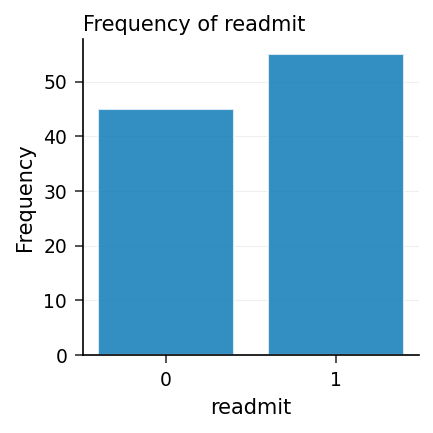

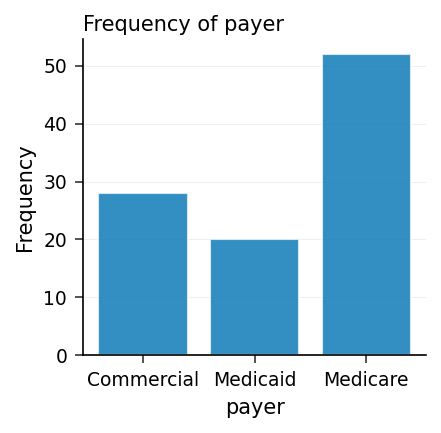

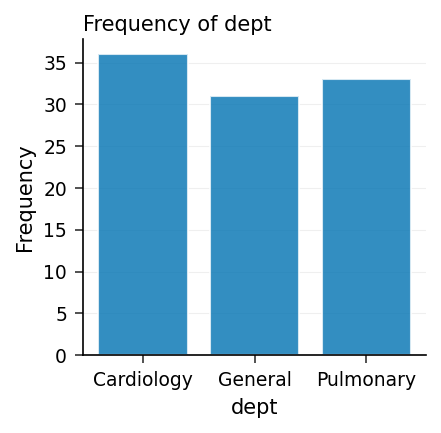

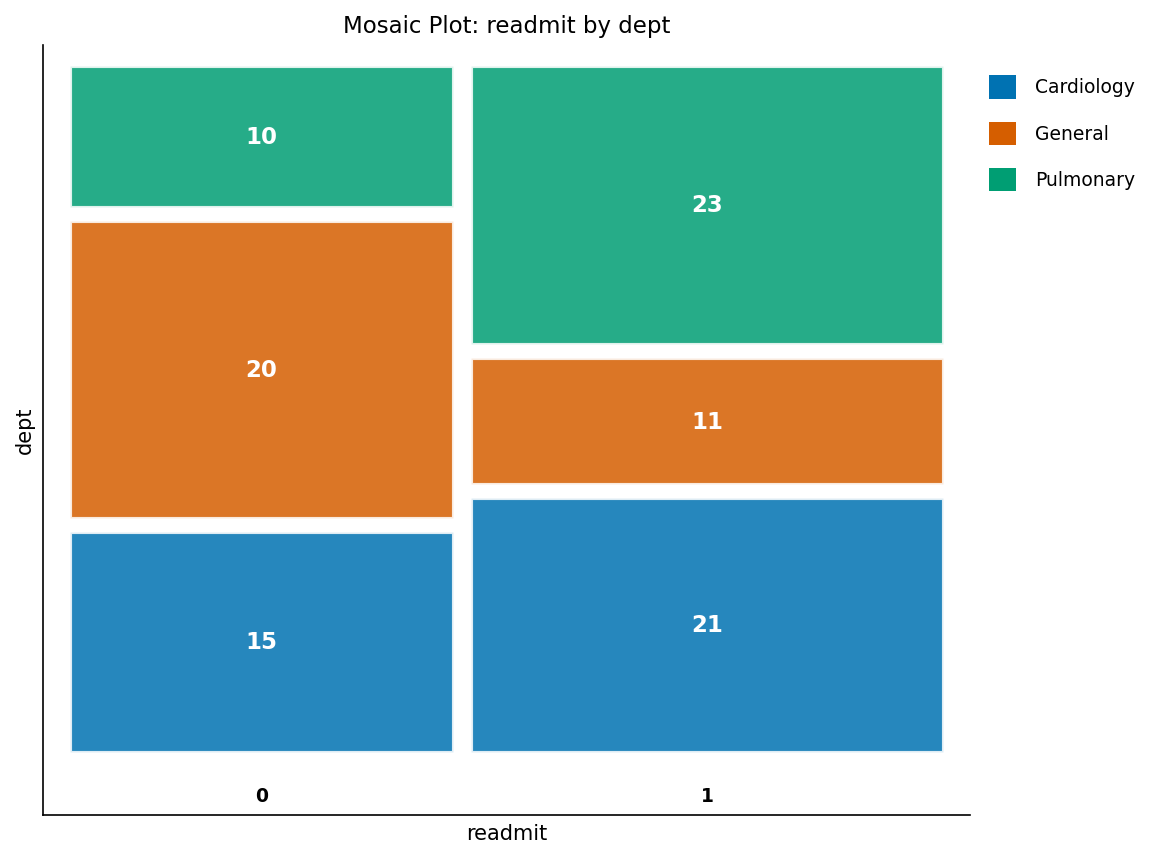

In [2]:
PROCÉDURE FRÉQUENCES DONNÉES=encounters;
    TABLES readmit payer dept readmit*dept / nocum nopercent;
    ÉTIQUETTE readmit="Réadmission (0/1)"
              payer="Payeur"
              dept="Service de sortie";
EXÉCUTER;

## Étape 3 — Ajuster le modèle logistique de réadmission

Nous modélisons `readmit` en fonction de l'âge, de la durée de séjour, du nombre de comorbidités, du nombre de médicaments à la sortie, du payeur et du département. Choix clés :

- `EVENT='1'` modélise la probabilité de réadmission (plutôt que de non-réadmission).
- `CLASS payer dept / PARAM=REF REF=FIRST` utilise un codage à cellule de référence de sorte que chaque niveau soit contrasté à une modalité de base (ici Medicare et Pulmonary).
- `CLODDS=WALD` et `RSQUARE` ajoutent des limites de confiance de Wald pour les rapports de cotes et un R-carré généralisé ; `LACKFIT` demande le test d'adéquation de Hosmer–Lemeshow.
- L'instruction `UNITS` demande le rapport de cotes pour un pas de durée de séjour cliniquement significatif de **5 jours** et un pas d'âge de **10 ans**, et l'instruction `ODDSRATIO` demande le rapport de cotes de comorbidité avec ses limites de confiance.

La table de rapports de cotes en sortie rapporte directement les effets par unité : la durée de séjour porte un OR de **1,36 par jour** (IC à 95 % 1,01–1,82), l'âge un OR de **1,05 par an**, et la couverture Medicaid un OR de **6,02** relativement à Medicare. Le modèle s'ajuste bien — R-carré généralisé 0,246, Hosmer–Lemeshow *p* = 0,73.


                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

              Response Profile              
  Probability modeled is Réadmission='1'   

Ordered Value  Réadmission   Total Frequency
-------------  ------------  ---------------
            1  0                          45
            2  1                          55

                 Class Level Information                 

Class                Levels  Values                      
-----------------  --------  ----------------------------
Payeur                    3  Commercial Medicaid Medicare
Service de sortie         3  Cardiology General Pulmonary

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: readmit Réadmission

Criterion     Value
---------  --------
AIC         127.335
-2 Log L    109.335
SC


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe
NOTE: PROC LOGISTIC data=encounters

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json
NOTE: ODS OUTPUT: All output destinations closed.


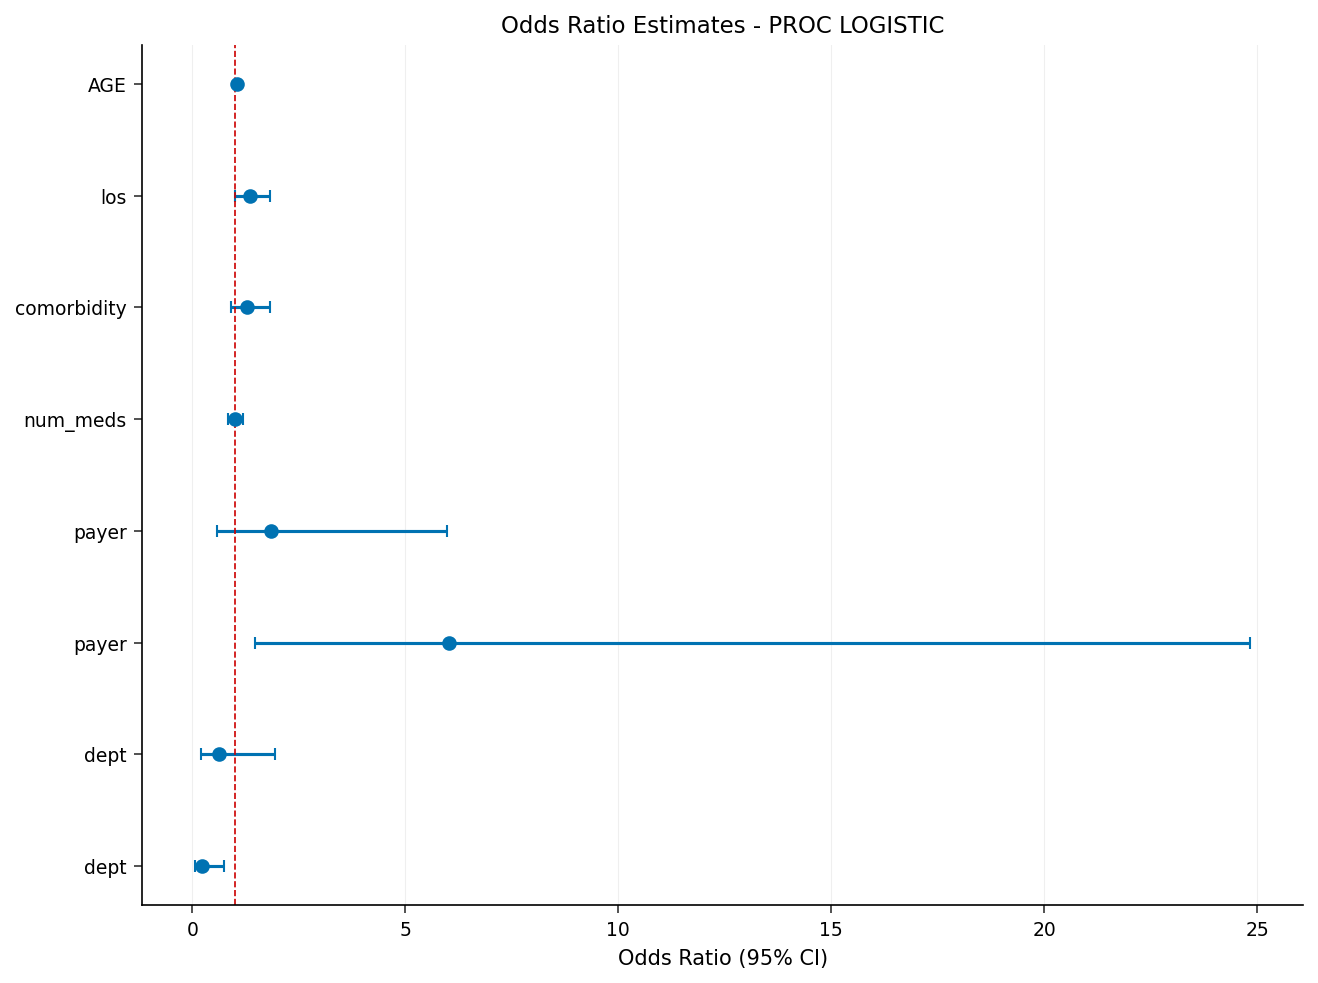

In [3]:
ODS SORTIE ParameterEstimates=pe;
PROCÉDURE LOGISTIQUE DONNÉES=encounters PLOTS(only)=oddsratio;
    CLASSE payer dept / PARAM=REF REF=first;
    MODÈLE readmit(EVENT='1') = AGE los comorbidity num_meds payer dept
          / clodds=wald rsquare lackfit;
    units AGE=10 los=5;
    oddsratio comorbidity / cl=wald;
    ÉTIQUETTE readmit="Réadmission"
              AGE="Âge (années)"
              los="Durée de séjour (jours)"
              comorbidity="Indice de comorbidité"
              num_meds="Nombre de médicaments"
              payer="Payeur"
              dept="Service de sortie";
EXÉCUTER;
ODS SORTIE CLOSE;

## Étape 4 — Capturer les coefficients ajustés

Les graphiques d'effets basés sur le modèle qui suivent sont construits directement à partir des coefficients *ajustés*, si bien qu'ils concordent toujours avec le modèle de l'Étape 3. Nous avons enregistré les estimations de paramètres avec `ODS OUTPUT ParameterEstimates=pe` ; ici, nous replions cette table longue en un jeu de données `params` d'une seule ligne (une variable par coefficient) et y ajoutons les moyennes de cohorte des prédicteurs continus. Maintenir les prédicteurs hors focus à leurs moyennes est exactement ce qu'un EFFECTPLOT fait en interne — cela laisse chaque graphique faire varier un facteur tout en gardant le reste fixé à un profil représentatif.


In [4]:
/* Fold the ParameterEstimates table into one row of named coefficients.
   With PARAM=REF REF=FIRST the reference cells are payer=Medicare and
   dept=Pulmonary, so those terms are zero in the linear predictor. */
DONNÉES coefs;
    RETENIR b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen 0;
    DÉFINIR pe FIN=last;
    VAR = upcase(strip(Variable));
    cv  = strip(ClassVal0);
    SI VAR='INTERCEPT' ALORS b0 = ESTIMATION;
    SINON SI VAR='AGE' ALORS b_age = ESTIMATION;
    SINON SI VAR='LOS' ALORS b_los = ESTIMATION;
    SINON SI VAR='COMORBIDITY' ALORS b_com = ESTIMATION;
    SINON SI VAR='NUM_MEDS' ALORS b_med = ESTIMATION;
    SINON SI VAR='PAYER' AND cv='Medicaid'   ALORS b_pmcaid = ESTIMATION;
    SINON SI VAR='PAYER' AND cv='Commercial' ALORS b_pcomm  = ESTIMATION;
    SINON SI VAR='DEPT'  AND cv='Cardiology' ALORS b_dcard  = ESTIMATION;
    SINON SI VAR='DEPT'  AND cv='General'    ALORS b_dgen   = ESTIMATION;
    SI last ALORS SORTIE;
    GARDER b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen;
EXÉCUTER;

/* Cohort means of the continuous covariates, held fixed in the plots. */
PROCÉDURE MOYENNES DONNÉES=encounters SANS_IMPRESSION;
    VAR AGE los comorbidity num_meds;
    SORTIE out=mn mean=m_age m_los m_com m_med;
EXÉCUTER;

DONNÉES params;
    FUSIONNER coefs mn;
    GARDER b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
         m_age m_los m_com m_med;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=params noobs;
    TITRE "Coefficients ajustés et moyennes des covariables pour les graphiques d'effets";
EXÉCUTER;

                     Coefficients ajustés et moyennes des covariables pour les graphiques d'effets                      

           b0         b_age         b_los         b_com         b_med      b_pmcaid       b_pcomm        b_dcard         b_dgen  m_age  m_los  m_com  m_med
-4.9220021175  0.0443054038  0.3052368368  0.2553476408  0.0005084625  1.7958084904  0.6128310257  -0.4493317481  -1.4957988173  70.53   4.59   2.88   7.08




NOTE: DATA coefs


NOTE: Read 9 rows from pe.
NOTE: Wrote coefs (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mn has 1 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA params

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=params

NOTE: PROC PRINT completed: 1 observations printed, 13 variables


## Étape 5 — Graphique d'ajustement : probabilité de réadmission en fonction de la durée de séjour

L'affichage d'effet le plus simple est une **courbe d'ajustement** : la probabilité de réadmission prédite en fonction d'une seule covariable continue, les autres prédicteurs étant maintenus à un profil représentatif. Nous construisons une grille de durée de séjour (1–18 jours), évaluons le prédicteur linéaire ajusté à chaque valeur pour un patient de **cardiologie Medicare** (âge, comorbidité et nombre de médicaments à la sortie fixés aux moyennes de cohorte de l'Étape 4), appliquons la logit inverse, et traçons la courbe à l'échelle de la probabilité avec PROC SGPLOT.


                     Coefficients ajustés et moyennes des covariables pour les graphiques d'effets                      




NOTE: DATA grid_los


NOTE: Wrote grid_los (18 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_los


NOTE: Read 18 rows from grid_los.
NOTE: Wrote fit_los (18 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_los

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


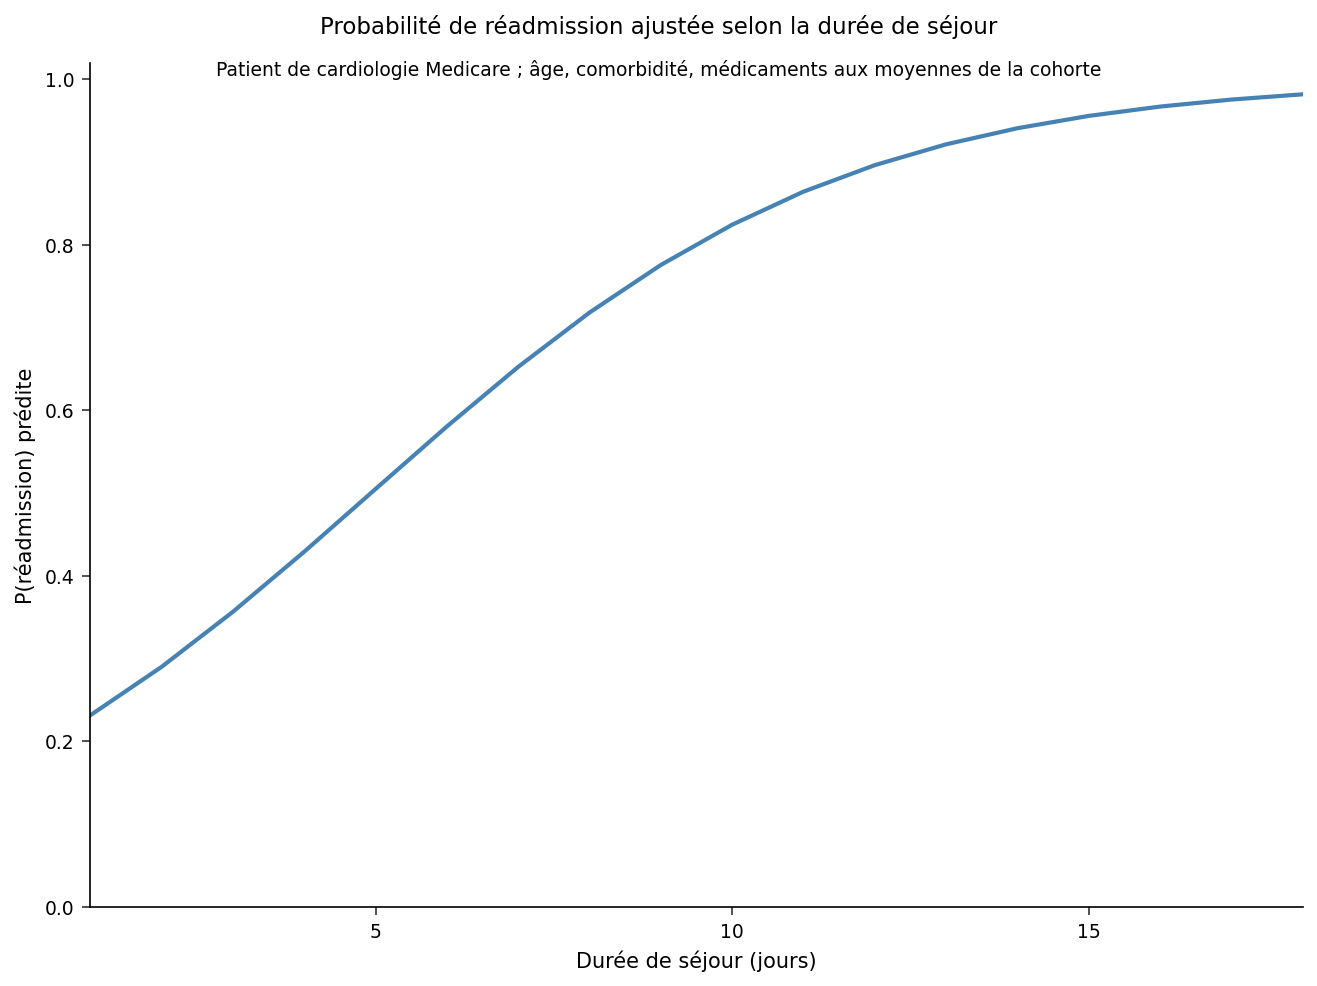

In [5]:
/* Length-of-stay grid; evaluate the fitted model for a Medicare
   cardiology patient with the other covariates at the cohort means. */
DONNÉES grid_los;
    FAIRE los = 1 JUSQU_À 18;
        SORTIE;
    FIN;
EXÉCUTER;

DONNÉES fit_los;
    DÉFINIR grid_los;
    SI _n_ = 1 ALORS DÉFINIR params;
    RETENIR b0 b_age b_los b_com b_med b_dcard m_age m_com m_med;
    /* Medicare payer is the reference (term = 0); Cardiology adds b_dcard */
    xb = b0 + b_age*m_age + b_los*los + b_com*m_com + b_med*m_med + b_dcard;
    phat = 1 / (1 + EXP(-xb));
    GARDER los phat;
EXÉCUTER;

PROCÉDURE SGPLOT DONNÉES=fit_los;
    SERIES x=los y=phat / LINEATTRS=(thickness=2 color=steelblue);
    TITRE  "Probabilité de réadmission ajustée selon la durée de séjour";
    title2 "Patient de cardiologie Medicare ; âge, comorbidité, médicaments aux moyennes de la cohorte";
    XAXIS ÉTIQUETTE="Durée de séjour (jours)";
    YAXIS ÉTIQUETTE="P(réadmission) prédite" VALUES=(0 JUSQU_À 1 PAR 0.2);
EXÉCUTER;

## Étape 6 — Ajustement en tranches : risque en fonction de l'âge, stratifié par payeur

Un **ajustement en tranches** trace une courbe ajustée par niveau d'un effet de classification — idéal pour montrer comment la composition des payeurs déplace le gradient âge–risque. Nous étendons la grille sur `age` (30–95) croisé avec les trois payeurs, évaluons le modèle ajusté pour un patient de Cardiology (durée de séjour, comorbidité et médicaments aux moyennes de cohorte), et superposons les trois courbes de probabilité avec `GROUP=payer`.


                     Coefficients ajustés et moyennes des covariables pour les graphiques d'effets                      




NOTE: DATA grid_age


NOTE: Wrote grid_age (42 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_age


NOTE: Read 42 rows from grid_age.
NOTE: Wrote fit_age (42 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_age

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


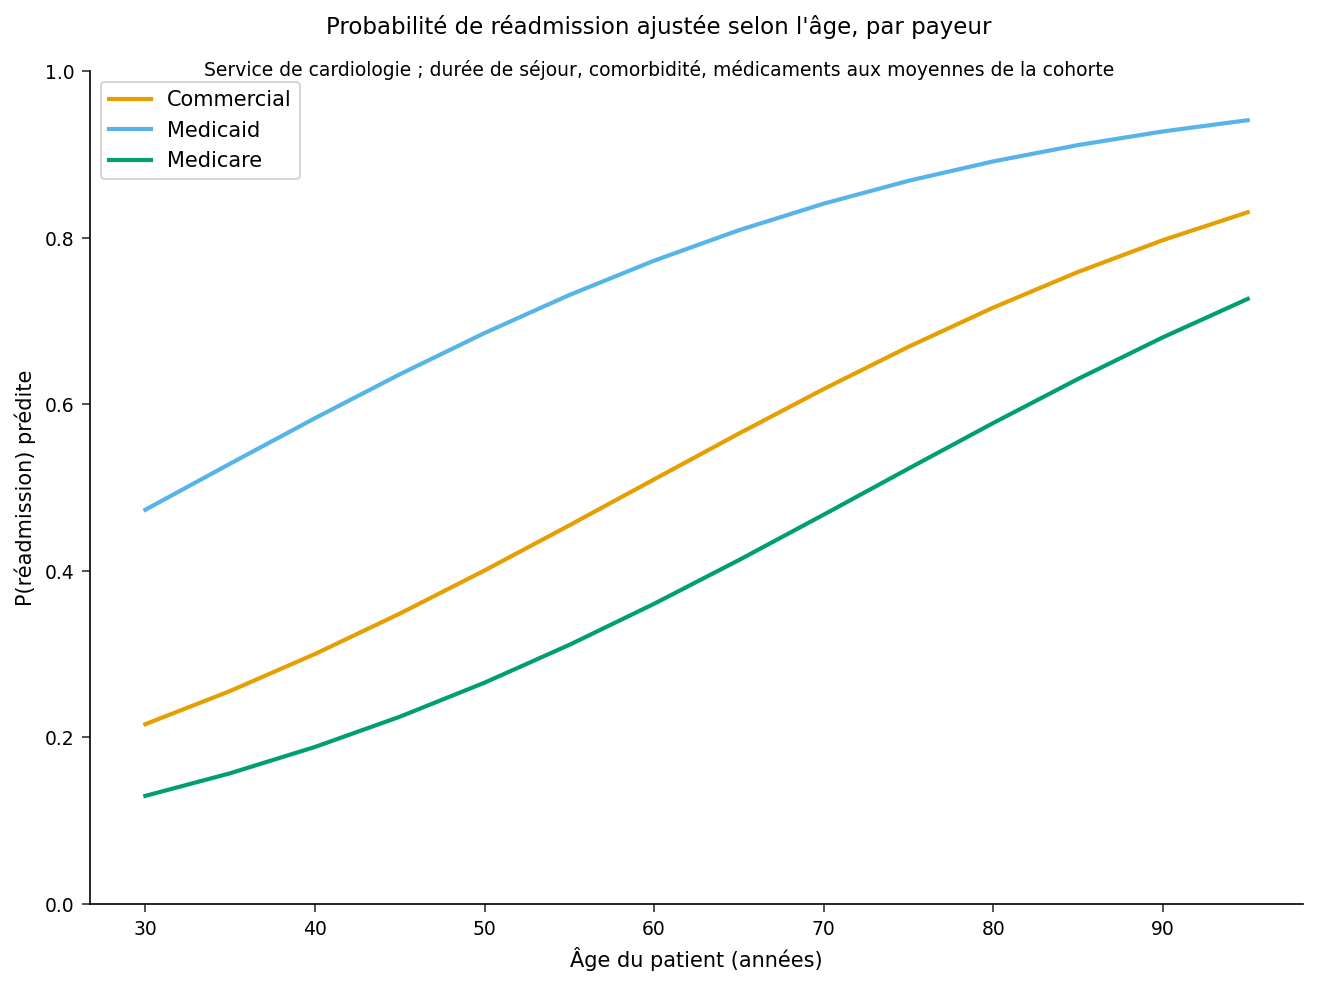

In [6]:
/* Age x payer grid for a Cardiology patient; other covariates at means. */
DONNÉES grid_age;
    LONGUEUR payer $12;
    FAIRE payer = 'Medicare', 'Medicaid', 'Commercial';
        FAIRE AGE = 30 JUSQU_À 95 PAR 5;
            SORTIE;
        FIN;
    FIN;
EXÉCUTER;

DONNÉES fit_age;
    DÉFINIR grid_age;
    SI _n_ = 1 ALORS DÉFINIR params;
    RETENIR b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard
           m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    xb = b0 + b_age*AGE + b_los*m_los + b_com*m_com + b_med*m_med
         + b_dcard + pay_term;
    phat = 1 / (1 + EXP(-xb));
    GARDER payer AGE phat;
EXÉCUTER;

PROCÉDURE SGPLOT DONNÉES=fit_age;
    SERIES x=AGE y=phat / GROUPE=payer LINEATTRS=(thickness=2);
    TITRE  "Probabilité de réadmission ajustée selon l'âge, par payeur";
    title2 "Service de cardiologie ; durée de séjour, comorbidité, médicaments aux moyennes de la cohorte";
    XAXIS ÉTIQUETTE="Âge du patient (années)";
    YAXIS ÉTIQUETTE="P(réadmission) prédite" VALUES=(0 JUSQU_À 1 PAR 0.2);
    keylegend / location=inside position=topleft ACROSS=1;
EXÉCUTER;

## Étape 7 — Affichage d'interaction : département par payeur

Pour comparer le risque prédit à travers les deux effets de classification en même temps, nous croisons `dept` avec `payer` (neuf combinaisons), évaluons le modèle ajusté avec chaque covariable continue à sa moyenne de cohorte, et traçons un diagramme à barres groupées avec `dept` sur l'axe X et le payeur comme regroupement. Comme ce modèle n'a pas de terme d'interaction département-par-payeur, l'ordre des payeurs est le même décalage additif à l'intérieur de chaque ligne de service — l'affichage rend cette additivité visible d'un coup d'œil, aux côtés du classement des départements.


                     Coefficients ajustés et moyennes des covariables pour les graphiques d'effets                      




NOTE: DATA grid_dx


NOTE: Wrote grid_dx (9 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_dx


NOTE: Read 9 rows from grid_dx.
NOTE: Wrote fit_dx (9 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_dx

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


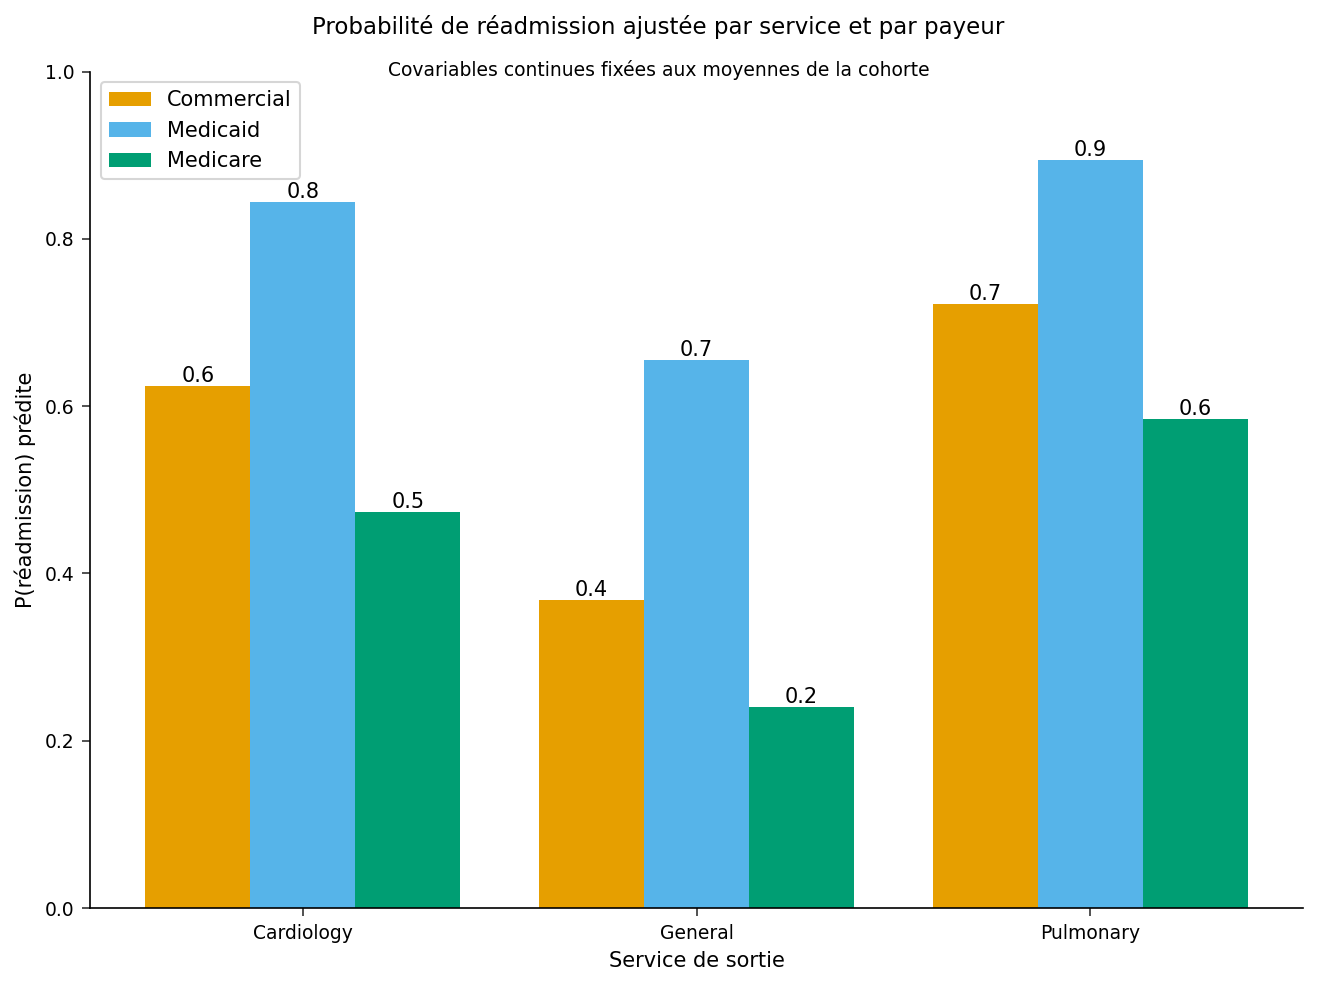

In [7]:
/* Department x payer grid; all continuous covariates at cohort means. */
DONNÉES grid_dx;
    LONGUEUR dept $12 payer $12;
    FAIRE dept = 'Cardiology', 'Pulmonary', 'General';
        FAIRE payer = 'Medicare', 'Medicaid', 'Commercial';
            SORTIE;
        FIN;
    FIN;
EXÉCUTER;

DONNÉES fit_dx;
    DÉFINIR grid_dx;
    SI _n_ = 1 ALORS DÉFINIR params;
    RETENIR b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
           m_age m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    dep_term = (dept='Cardiology')*b_dcard + (dept='General')*b_dgen;
    xb = b0 + b_age*m_age + b_los*m_los + b_com*m_com + b_med*m_med
         + pay_term + dep_term;
    phat = 1 / (1 + EXP(-xb));
    GARDER dept payer phat;
EXÉCUTER;

PROCÉDURE SGPLOT DONNÉES=fit_dx;
    VBAR dept / RESPONSE=phat GROUPE=payer GROUPDISPLAY=GRAPPE
                DATALABEL datalabelattrs=(size=8);
    TITRE  "Probabilité de réadmission ajustée par service et par payeur";
    title2 "Covariables continues fixées aux moyennes de la cohorte";
    XAXIS ÉTIQUETTE="Service de sortie";
    YAXIS ÉTIQUETTE="P(réadmission) prédite" VALUES=(0 JUSQU_À 1 PAR 0.2);
EXÉCUTER;

## Étape 8 — Interprétation des résultats

Les graphiques d'effets transforment le modèle ajusté PROC LOGISTIC en images à l'échelle de la probabilité qui se rattachent aux décisions de gestion des soins :

- **Durée de séjour (courbe d'ajustement).** Pour un patient de cardiologie Medicare aux moyennes de cohorte, la probabilité de réadmission prédite grimpe d'environ **0,23 pour un séjour d'1 jour à environ 0,82 à 10 jours et ~0,98 à 18 jours** — le milieu abrupt de la courbe logistique. C'est le même signal que le rapport de cotes de durée de séjour de **1,36 par jour** (`UNITS los=5` le remet à l'échelle d'un pas de cinq jours), et il signale les longs séjours index comme un déclencheur concret d'inscription en soins de transition.
- **Âge et payeur (ajustement en tranches).** Le risque augmente de façon monotone avec l'âge pour chaque payeur, et les trois courbes ne se croisent jamais : la courbe **Medicaid** se situe la plus haute à tout âge donné, **Commercial** au milieu, et **Medicare** la plus basse — cohérent avec les rapports de cotes de payeur ajustés (Medicaid 6,02, Commercial 1,85, tous deux relativement à Medicare). L'écart est le plus grand aux âges jeunes et se resserre à mesure que tous approchent d'une probabilité élevée, orientant l'attention de la gestion des soins vers les patients Medicaid plus jeunes qui paraîtraient autrement à faible risque.
- **Département et payeur (affichage d'interaction).** Le service **Pulmonary** porte la probabilité de réadmission prédite la plus élevée dans chaque groupe de payeurs, **Cardiology** est intermédiaire, et **General medicine** est le plus bas (les rapports de cotes de département ajustés sont de 0,64 pour Cardiology et 0,22 pour General, relativement à Pulmonary). Comme le modèle n'a pas de terme d'interaction département-par-payeur, l'ordre des payeurs est le même décalage additif à l'intérieur de chaque ligne de service — les barres montent dans le même ordre Medicaid > Commercial > Medicare à chaque département.

**À retenir :** plutôt que de demander aux cliniciens d'interpréter des coefficients en log-cotes, les graphiques d'effets basés sur le modèle présentent le modèle de réadmission ajusté sous forme d'images à l'échelle de la probabilité — qui inscrire en suivi de soins de transition, et quelles lignes de service et populations de payeurs prioriser. SAS produit ceux-ci directement via `EFFECTPLOT` ; ici, nous avons reconstruit les courbes identiques à partir des coefficients ajustés afin que l'exemple s'exécute de bout en bout dès aujourd'hui.
